In [16]:
# Martin Konečnik, https://git.siwim.si/machine-learning/fix-qa-binary-classification
# Notebook intended for testing existing models.
import pickle
import tomllib
from pathlib import Path

import numpy as np
import torch

# Initialize CUDA.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [17]:
# Read the configuration file.
with open('conf.toml', 'rb') as f:
    conf = tomllib.load(f)

LOAD_MODEL = conf['model']
EVENTS_PATH = Path().home() / conf['data_dir'] / 'prepared'

In [18]:
# Load the model.
from classifier import BinaryClassifier

dim = int(open(Path('models', LOAD_MODEL, 'dimensions')).read())
model = BinaryClassifier(input_dim=dim).to(device)
model.load_state_dict(torch.load(f'models/{LOAD_MODEL}/fix-qa-binary-classification.pth', map_location=device))
model.eval()

BinaryClassifier(
  (relu): ReLU()
  (conv1): Conv1d(1, 128, kernel_size=(51,), stride=(1,), padding=(25,))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(128, 64, kernel_size=(25,), stride=(1,), padding=(12,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (conv3): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.25, inplace=False)
  (conv4): Conv1d(64, 32, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (residual_projection): Conv1d(128, 32, kernel_size=(1,), stride=(1,))
  (attention): Sequential(
    (0): Conv1d(32, 1, kernel_size=(1,), 

In [19]:
test_on_all = False

if test_on_all:
    unaltered_pkl_path = EVENTS_PATH / 'unaltered.pkl'
else:
    unaltered_pkl_path = Path('test_data') / 'unaltered.pkl'
corrected_pkl_path = Path('test_data') / 'corrected.pkl'

# Read the pickled arrays.
with open(unaltered_pkl_path, 'rb') as f:
    test_unaltered = pickle.load(f)
    if test_on_all:
        result = [[] for _ in range(len(test_unaltered))]
        print(f'Processing {len(test_unaltered)} channels ...')
        for i, veh in enumerate(test_unaltered):
            print(f'Processing {len(veh)} signals for channel {i} ...')
            for signal in veh:  # Normalize the signals.
                result[i].append(np.pad(signal - signal[0], (0, dim - len(signal)), mode='edge'))
        test_unaltered = np.array([sublist[:-200] for sublist in result])
with open(corrected_pkl_path, 'rb') as f:
    test_corrected = pickle.load(f)

Processing 8 channels ...
Processing 60309 signals for channel 0 ...
Processing 60309 signals for channel 1 ...
Processing 60309 signals for channel 2 ...
Processing 60309 signals for channel 3 ...
Processing 60309 signals for channel 4 ...
Processing 60309 signals for channel 5 ...
Processing 60309 signals for channel 6 ...
Processing 60309 signals for channel 7 ...


In [20]:
from sklearn.metrics import fbeta_score

print(f'Oblika test_corrected: {test_corrected.shape}')
print(f'Oblika test_unaltered: {test_unaltered.shape}')

# Povprečenje čez vse kanale (enako kot pri učnih podatkih v celici [6])
test_corrected_avg = np.mean(test_corrected, axis=0)  # [n_test_corrected, max_length]
test_unaltered_avg = np.mean(test_unaltered, axis=0)  # [n_test_unaltered, max_length]

print(f'\nPo povprečenju kanalov:')
print(f'  test_corrected_avg: {test_corrected_avg.shape}')
print(f'  test_unaltered_avg: {test_unaltered_avg.shape}')

# Priprava podatkov za model
X_test = torch.from_numpy(np.vstack((test_corrected_avg, test_unaltered_avg))).unsqueeze(1).float().to(device)
y_test = torch.from_numpy(np.array([1] * len(test_corrected_avg) + [0] * len(test_unaltered_avg))).to(device)

print(f'\nX_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'  - Popravljenih: {torch.sum(y_test).item()}')
print(f'  - Nepopravljenih: {len(y_test) - torch.sum(y_test).item()}')

# Testiranje modela v batchih
threshold = 0.2
model.eval()

batch_size = 32  # Zmanjšajte če še vedno zmanjka pomnilnika
all_probabilities = []

with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        batch = X_test[i:i + batch_size]
        outputs = model(batch)
        probabilities = torch.sigmoid(outputs)
        all_probabilities.append(probabilities.cpu())

        # Po potrebi sprostite pomnilnik
        del outputs, probabilities
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# Združite vse batche
probabilities = torch.cat(all_probabilities, dim=0)
predictions = (probabilities > threshold).float().numpy().flatten()
y_test_np = y_test.cpu().numpy().flatten()

# Metrike
from sklearn.metrics import f1_score, confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test_np, predictions).ravel()
f1 = f1_score(y_test_np, predictions)
f3 = fbeta_score(y_test_np, predictions, beta=3)

print("\n" + "=" * 60)
print(f"📊 REZULTATI NA TESTNIH SIGNALIH (prag = {threshold})")
print("=" * 60)
print(f"F1 Score: {f1:.4f}")
print(f"F3 Score: {f3:.4f}")
print(f"\nKonfuzijska matrika:")
print(f"  • TP (pravilno popravljenih):  {tp}")
print(f"  • FN (spregledanih):           {fn}")
print(f"  • TN (pravilno nepopravljenih): {tn}")
print(f"  • FP (lažnih alarmov):         {fp}")
print(f"\nDeleži:")
print(f"  • Odkritih popravljenih: {tp / (tp + fn) * 100:.1f}%")
print(f"  • Nepopravljenih, ki jih ni treba preverjati: {tn / (tn + fp) * 100:.1f}%")

Oblika test_corrected: (8, 100, 4329)
Oblika test_unaltered: (8, 60109, 4329)

Po povprečenju kanalov:
  test_corrected_avg: (100, 4329)
  test_unaltered_avg: (60109, 4329)

X_test shape: torch.Size([60209, 1, 4329])
y_test shape: torch.Size([60209])
  - Popravljenih: 100
  - Nepopravljenih: 60109

📊 REZULTATI NA TESTNIH SIGNALIH (prag = 0.2)
F1 Score: 0.0312
F3 Score: 0.1378

Konfuzijska matrika:
  • TP (pravilno popravljenih):  94
  • FN (spregledanih):           6
  • TN (pravilno nepopravljenih): 54280
  • FP (lažnih alarmov):         5829

Deleži:
  • Odkritih popravljenih: 94.0%
  • Nepopravljenih, ki jih ni treba preverjati: 90.3%


In [21]:
import torch
from tqdm import tqdm  # Optional: for progress bars


def get_all_predictions_batched(model, test_corrected, test_unaltered, batch_size=32):
    """
    Get predictions for all test data using batching to avoid OOM.
    Returns probabilities and labels.
    """
    model.eval()

    # Povprečenje kanalov
    test_corrected_avg = np.mean(test_corrected, axis=0)  # Shape: (n_corrected, 6000)
    test_unaltered_avg = np.mean(test_unaltered, axis=0)  # Shape: (n_unaltered, 6000)

    print(f"Data shapes after averaging:")
    print(f"  Corrected: {test_corrected_avg.shape}")
    print(f"  Unaltered: {test_unaltered_avg.shape}")

    # Combine data
    X_test = np.vstack((test_corrected_avg, test_unaltered_avg))
    y_test = np.array([1] * len(test_corrected_avg) + [0] * len(test_unaltered_avg))

    n_samples = len(X_test)
    print(f"Total test samples: {n_samples}")
    print(f"  Corrected: {np.sum(y_test)}")
    print(f"  Unaltered: {n_samples - np.sum(y_test)}")

    # Process in batches
    all_probabilities = []

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Predicting"):
            # Get batch
            batch_X = X_test[i:i + batch_size]

            # Convert to tensor
            batch_tensor = torch.from_numpy(batch_X).unsqueeze(1).float()

            # Move to device (CPU or GPU based on availability)
            batch_tensor = batch_tensor.to(device)

            # Forward pass
            outputs = model(batch_tensor)
            probabilities = torch.sigmoid(outputs).cpu().numpy().flatten()

            all_probabilities.extend(probabilities)

            # Clean up GPU memory if needed
            if torch.cuda.is_available():
                del batch_tensor, outputs
                torch.cuda.empty_cache()

    probabilities = np.array(all_probabilities)

    return probabilities, y_test


def calculate_metrics_at_threshold(probabilities, y_true, threshold):
    """Calculate all metrics for a given threshold."""
    predictions = (probabilities > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

    # Precision, Recall, F3
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if precision + recall > 0:
        f3 = 10 * (precision * recall) / (9 * precision + recall)
    else:
        f3 = 0

    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0

    # Positive Rate (Flag Rate) - proportion of samples predicted as positive
    positive_rate = (tp + fp) / len(y_true) if len(y_true) > 0 else 0

    # Workload reduction (1 - positive_rate)
    workload_reduction = 1 - positive_rate

    return {
        'threshold': threshold,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'f3': f3, 'accuracy': accuracy,
        'positive_rate': positive_rate,
        'workload_reduction': workload_reduction,
        'n_corrected': tp + fn, 'n_unaltered': tn + fp
    }


def evaluate_thresholds(model, test_corrected, test_unaltered,
                        thresholds=[0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99],
                        batch_size=32):
    """
    Main evaluation function - gets predictions once and evaluates all thresholds.
    This is MUCH more efficient than calling get_values_at_threshold_test repeatedly.
    """
    # Get predictions once (the expensive part)
    print("\n" + "=" * 60)
    print("Getting model predictions...")
    print("=" * 60)
    probabilities, y_true = get_all_predictions_batched(model, test_corrected, test_unaltered, batch_size)

    # Evaluate all thresholds
    print("\n" + "=" * 115)
    print("REZULTATI PRI RAZLIČNIH PRAGOVIH (TESTNI PODATKI)")
    print("=" * 115)
    print(f"{'Prag':>6} | {'TP':>5} | {'TN':>5} | {'FP':>5} | {'FN':>5} | {'Prec':>6} | {'Recall':>7} | {'F3':>6} | {'Acc':>6} | {'PosRate':>8} | {'WkldRed':>8}")
    print("-" * 115)

    results = []
    for threshold in thresholds:
        metrics = calculate_metrics_at_threshold(probabilities, y_true, threshold)
        results.append(metrics)
        print(f"{metrics['threshold']:>6.2f} | {metrics['tp']:>5} | {metrics['tn']:>5} | {metrics['fp']:>5} | {metrics['fn']:>5} | "
              f"{metrics['precision']:>6.3f} | {metrics['recall']:>7.3f} | {metrics['f3']:>6.3f} | {metrics['accuracy']:>6.3f} | "
              f"{metrics['positive_rate']:>8.3f} | {metrics['workload_reduction']:>8.3f}")

    print("=" * 115)
    print("\n📌 POJASNILO METRIK:")
    print("   • PosRate (Positive Rate): delež vzorcev, ki jih model označi kot 'popravljeno' = (TP+FP)/Total")
    print("   • WkldRed (Workload Reduction): delež podatkov, ki jih expert NE rabi pregledati = 1 - PosRate")
    print("   • Recall: delež dejansko popravljenih, ki so bili odkriti")
    print("   • Precision: točnost napovedi 'popravljeno'")
    print("   • F3: utežena harmonična sredina (recall 3× bolj ponderiran)")
    print("   • FN: spregledana popravljena vozila (kritično!)")

    # Find best accuracy
    best_acc_idx = np.argmax([r['accuracy'] for r in results])
    print(f"\n📈 Najboljša točnost (Accuracy): {results[best_acc_idx]['accuracy'] * 100:.2f}% pri pragu {results[best_acc_idx]['threshold']:.3f}")

    # Find best F3
    best_f3_idx = np.argmax([r['f3'] for r in results])
    print(f"📈 Najboljši F3 score: {results[best_f3_idx]['f3']:.4f} pri pragu {results[best_f3_idx]['threshold']:.3f}")

    # Find best workload reduction with acceptable recall (e.g., recall > 0.95)
    good_recall_idx = [i for i, r in enumerate(results) if r['recall'] >= 0.95]
    if good_recall_idx:
        best_wkld_idx = min(good_recall_idx, key=lambda i: results[i]['positive_rate'])
        best_wkld = results[best_wkld_idx]
        print(f"\n💼 Najboljša redukcija dela pri ohranjenem recall-u ≥95%:")
        print(f"   • Workload reduction: {best_wkld['workload_reduction'] * 100:.1f}% (pregledate le {best_wkld['positive_rate'] * 100:.1f}% podatkov)")
        print(f"   • Pri pragu: {best_wkld['threshold']:.3f}")
        print(f"   • Recall: {best_wkld['recall']:.3f}")

    # Print detailed results for best F3
    best = results[best_f3_idx]
    print(f"\n🌟 NAJBOLJŠI F3 SCORE (prag = {best['threshold']:.3f}):")
    print(f"   • F3: {best['f3']:.4f}")
    print(f"   • Recall: {best['recall']:.4f}")
    print(f"   • Precision: {best['precision']:.4f}")
    print(f"   • Accuracy: {best['accuracy'] * 100:.1f}%")
    print(f"   • Positive Rate: {best['positive_rate'] * 100:.1f}% (flag rate)")
    print(f"   • Workload Reduction: {best['workload_reduction'] * 100:.1f}%")
    print(f"   • TP: {best['tp']}, FN: {best['fn']} (spregledanih popravljenih)")
    print(f"   • TN: {best['tn']}, FP: {best['fp']} (lažnih alarmov)")

    return results, probabilities, y_true


# ============================================================================
# SIMPLIFIED USAGE
# ============================================================================

# Parameters
thresholds = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
batch_size = 32  # Adjust based on your memory (try 16, 32, 64)

print(f"\n🚀 Starting evaluation with batch_size={batch_size}")
print(f"   Device: {device}")

# Run evaluation
results, probabilities, y_true = evaluate_thresholds(
    model,
    test_corrected,
    test_unaltered,
    thresholds=thresholds,
    batch_size=batch_size
)


🚀 Starting evaluation with batch_size=32
   Device: cuda

Getting model predictions...
Data shapes after averaging:
  Corrected: (100, 4329)
  Unaltered: (60109, 4329)
Total test samples: 60209
  Corrected: 100
  Unaltered: 60109


Predicting: 100%|██████████| 1882/1882 [00:19<00:00, 94.37it/s]



REZULTATI PRI RAZLIČNIH PRAGOVIH (TESTNI PODATKI)
  Prag |    TP |    TN |    FP |    FN |   Prec |  Recall |     F3 |    Acc |  PosRate |  WkldRed
-------------------------------------------------------------------------------------------------------------------
  0.01 |    99 | 45176 | 14933 |     1 |  0.007 |   0.990 |  0.062 |  0.752 |    0.250 |    0.750
  0.05 |    97 | 51195 |  8914 |     3 |  0.011 |   0.970 |  0.098 |  0.852 |    0.150 |    0.850
  0.10 |    95 | 52912 |  7197 |     5 |  0.013 |   0.950 |  0.116 |  0.880 |    0.121 |    0.879
  0.20 |    94 | 54280 |  5829 |     6 |  0.016 |   0.940 |  0.138 |  0.903 |    0.098 |    0.902
  0.30 |    92 | 55017 |  5092 |     8 |  0.018 |   0.920 |  0.151 |  0.915 |    0.086 |    0.914
  0.40 |    91 | 55535 |  4574 |     9 |  0.020 |   0.910 |  0.164 |  0.924 |    0.077 |    0.923
  0.50 |    89 | 56051 |  4058 |    11 |  0.021 |   0.890 |  0.176 |  0.932 |    0.069 |    0.931
  0.60 |    87 | 56556 |  3553 |    13 |  0.024 |


📊 Business metrics analysis:
  • Best workload reduction with recall ≥95%: 89.5%
    (review 10.5% of data) at threshold 0.162
  • Best workload reduction with perfect recall: 0.0%
    (review 100.0% of data) at threshold 0.000


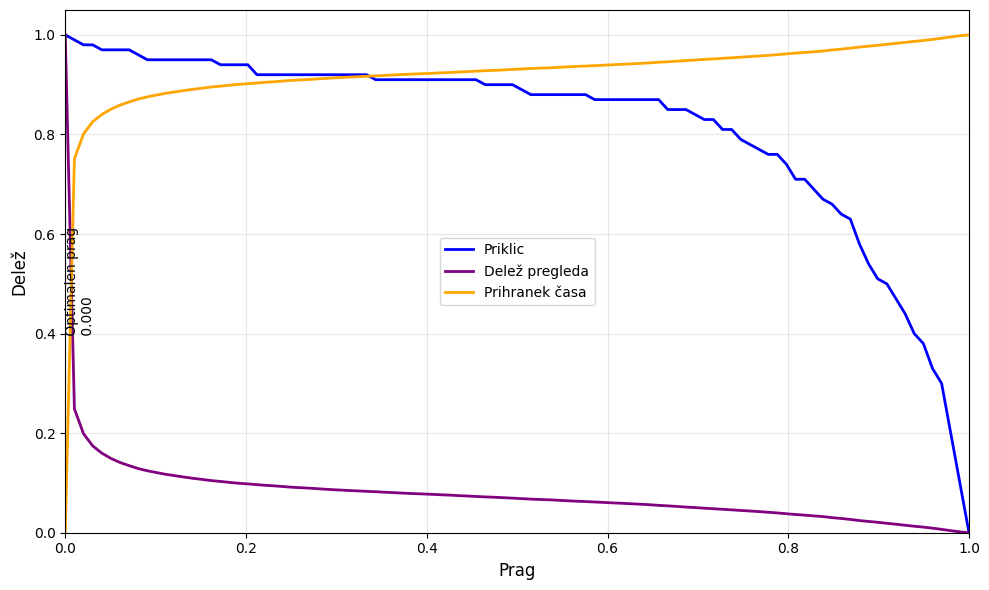


DETAILNI REZULTATI ZA PRAG 0.20
  tp: 94
  tn: 54280
  fp: 5829
  fn: 6
  precision: 0.01587033597838933
  recall: 0.94
  f3: 0.1377693096878206
  accuracy: 0.9030875782690295
  positive_rate: 0.0983739972429371
  workload_reduction: 0.9016260027570628
  n_corrected: 100
  n_unaltered: 60109


In [22]:
import matplotlib.pyplot as plt


def plot_metrics(probabilities, y_true):
    """Plot business metrics vs threshold (single graph)."""
    thresholds = np.linspace(0.00, 1.00, 100)
    recalls = []
    positive_rates = []
    workload_reductions = []

    for threshold in thresholds:
        predictions = (probabilities > threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        positive_rate = (tp + fp) / len(y_true) if len(y_true) > 0 else 0
        workload_reduction = 1 - positive_rate

        recalls.append(recall)
        positive_rates.append(positive_rate)
        workload_reductions.append(workload_reduction)

    # Print summary
    print("\n📊 Business metrics analysis:")

    # Find threshold where recall first drops below 0.95
    high_recall_idx = [i for i, r in enumerate(recalls) if r >= 0.95]
    if high_recall_idx:
        best_wkld_idx = min(high_recall_idx, key=lambda i: positive_rates[i])
        print(f"  • Best workload reduction with recall ≥95%: {workload_reductions[best_wkld_idx] * 100:.1f}%")
        print(f"    (review {positive_rates[best_wkld_idx] * 100:.1f}% of data) at threshold {thresholds[best_wkld_idx]:.3f}")

    # Find threshold with perfect recall (100%)
    perfect_recall_idx = [i for i, r in enumerate(recalls) if r == 1.0]
    if perfect_recall_idx:
        min_work_idx = min(perfect_recall_idx, key=lambda i: positive_rates[i])
        print(f"  • Best workload reduction with perfect recall: {workload_reductions[min_work_idx] * 100:.1f}%")
        print(f"    (review {positive_rates[min_work_idx] * 100:.1f}% of data) at threshold {thresholds[min_work_idx]:.3f}")

    plt.figure(figsize=(10, 6))

    # Plot all three metrics
    plt.plot(thresholds, recalls, 'b-', label='Priklic', linewidth=2)
    plt.plot(thresholds, positive_rates, 'purple', label='Delež pregleda', linewidth=2)
    plt.plot(thresholds, workload_reductions, 'orange', label='Prihranek časa', linewidth=2)

    # Mark the optimal point for perfect recall
    if perfect_recall_idx:
        opt_idx = min(perfect_recall_idx, key=lambda i: positive_rates[i])
        plt.axvline(x=thresholds[opt_idx], color='red', linestyle='--', alpha=0.5)
        plt.text(thresholds[opt_idx], 0.5, f' Optimalen prag\n {thresholds[opt_idx]:.3f}',
                 rotation=90, verticalalignment='center')

    plt.xlabel('Prag', fontsize=12)
    plt.ylabel('Delež', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    return thresholds, recalls, positive_rates, workload_reductions


# Plot business metrics (single graph with recall, positive rate, workload reduction)
plot_metrics(probabilities, y_true)

# Get specific threshold (e.g., 0.2)
print("\n" + "=" * 60)
print(f"DETAILNI REZULTATI ZA PRAG 0.20")
print("=" * 60)
specific_result = calculate_metrics_at_threshold(probabilities, y_true, threshold=0.20)
for key, value in specific_result.items():
    if key != 'threshold':
        print(f"  {key}: {value}")

In [23]:
# Recommended thresholds

import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix

graph_font = 20

# ---- 1. Priprava podatkov ----
model.eval()

test_corrected_avg = np.mean(test_corrected, axis=0)  # (100, 4329)
test_unaltered_avg = np.mean(test_unaltered, axis=0)  # (200, 4329)

X_test = np.vstack((test_corrected_avg, test_unaltered_avg))  # (300, 4329)
y_test = np.array([1] * len(test_corrected_avg) + [0] * len(test_unaltered_avg))  # (300,)

X_test_tensor = torch.from_numpy(X_test).unsqueeze(1).float().to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

with torch.no_grad():
    probabilities = torch.sigmoid(model(X_test_tensor)).cpu().numpy().flatten()

y_true = y_test_tensor.cpu().numpy().flatten()

print(f"Testni podatki: {len(y_true)} vzorcev (100 popravljenih, 200 nepopravljenih)")

# ---- 2. ROC krivulja z AUC ----
fpr, tpr, _ = roc_curve(y_true, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC krivulja (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Naključni klasifikator')
plt.xlabel('Delež lažnih alarmov (FPR)', fontsize=graph_font)
plt.ylabel('Priklic (TPR)', fontsize=graph_font)
plt.legend(loc='lower right', fontsize=graph_font - 2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 3. PR krivulja z AP (povprečna preciznost) ----
precision, recall, _ = precision_recall_curve(y_true, probabilities)
ap_score = average_precision_score(y_true, probabilities)
baseline = np.sum(y_true) / len(y_true)  # = 100/300 = 0.333

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'PR krivulja (AP = {ap_score:.3f})')
plt.axhline(y=baseline, color='black', linestyle='--', linewidth=1, label=f'Naključni klasifikator')
plt.xlabel('Priklic', fontsize=graph_font)
plt.ylabel('Natančnost', fontsize=graph_font)
plt.legend(loc='lower left', fontsize=graph_font - 2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 4. Krivulja priklica v odvisnosti od praga (za optimizacijo FN) ----
thresholds = np.linspace(0.00, 1.00, 100)
recalls = []
specificities = []
precisions = []
accuracies = []
fn_counts = []

for threshold in thresholds:
    predictions = (probabilities > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    recalls.append(recall)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    precisions.append(precision)
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    accuracies.append(accuracy)
    fn_counts.append(fn)

# Izris priklica v odvisnosti od praga
plt.figure(figsize=(8, 6))
plt.plot(thresholds, recalls, 'b-', linewidth=2, label='Priklic')
plt.xlabel('Prag', fontsize=graph_font)
plt.ylabel('Priklic', fontsize=graph_font)
plt.legend(loc='upper right', fontsize=graph_font - 2)
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- 5. Dodatni graf: FN v odvisnosti od praga ----
plt.figure(figsize=(8, 6))
plt.plot(thresholds, fn_counts, 'r-', linewidth=2, label='Število spregledanih (FN)')
plt.xlabel('Prag', fontsize=graph_font)
plt.ylabel('Število spregledanih (FN)', fontsize=graph_font)
plt.legend(loc='upper right', fontsize=graph_font - 2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 6. Izpis priporočenega praga ----
# Poišči prag, kjer je FN <= 1 (če obstaja)
fn_array = np.array(fn_counts)
thresholds_array = np.array(thresholds)

# Prag z najvišjim priklicom, kjer je FN <= 1
mask = fn_array <= 1
if np.any(mask):
    best_idx = np.where(mask)[0][-1]  # zadnji prag z FN <= 1 (najvišji prag)
    best_threshold = thresholds_array[best_idx]
    best_recall = recalls[best_idx]
    best_fn = fn_counts[best_idx]
    print(f"\n📌 Priporočen prag: {best_threshold:.3f}")
    print(f"   • Priklic: {best_recall:.4f} ({100 - best_recall * 100:.1f}% spregledanih)")
    print(f"   • Spregledanih (FN): {best_fn}")
else:
    # Če ni praga z FN <= 1, izberi prag z najmanj FN
    min_fn_idx = np.argmin(fn_counts)
    best_threshold = thresholds_array[min_fn_idx]
    best_recall = recalls[min_fn_idx]
    best_fn = fn_counts[min_fn_idx]
    print(f"\n📌 Priporočen prag (min FN): {best_threshold:.3f}")
    print(f"   • Priklic: {best_recall:.4f} ({100 - best_recall * 100:.1f}% spregledanih)")
    print(f"   • Spregledanih (FN): {best_fn}")

# ---- 6. F3 metrika v odvisnosti od praga ----
thresholds = np.linspace(0.00, 1.00, 100)
f3_scores = []

for threshold in thresholds:
    predictions = (probabilities > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # F3 = 10 * (P * R) / (9 * P + R)
    if precision + recall > 0:
        f3 = 10 * (precision * recall) / (9 * precision + recall)
    else:
        f3 = 0
    f3_scores.append(f3)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, f3_scores, 'purple', linewidth=2, label='F3 metrika')
plt.xlabel('Prag', fontsize=graph_font)
plt.ylabel('F3', fontsize=graph_font)
plt.legend(loc='upper right', fontsize=graph_font - 2)
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- 7. Izpis najboljšega F3 ----
f3_array = np.array(f3_scores)
best_f3_idx = np.argmax(f3_array)
best_f3_threshold = thresholds[best_f3_idx]
best_f3 = f3_array[best_f3_idx]

print(f"\n🏆 Najboljša vrednost F3: {best_f3:.4f} pri pragu {best_f3_threshold:.3f}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 124.29 GiB. GPU 0 has a total capacity of 23.75 GiB of which 17.74 GiB is free. Process 1099545 has 620.00 MiB memory in use. Process 3453037 has 232.64 MiB memory in use. Including non-PyTorch memory, this process has 3.17 GiB memory in use. Of the allocated memory 2.92 GiB is allocated by PyTorch, and 17.10 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)